# [SOLUTIONS] Lab 2 — Neural Architecture Search HW-aware on HW-NAS-Bench

## Search space, estimation strategy, and simple search algorithms

In this lab, we will work with a tabular benchmark: a CSV file extracted from [HW-NAS-Bench](https://openreview.net/pdf?id=_0kaDkv3dVf$0), which contains, for each architecture in the [NAS-Bench-201](https://openreview.net/forum?id=HJxyZkBKDr$0) search space, the accuracy obtained after training and several hardware metrics (latency, energy, ...) measured on different devices.

Having a tabular benchmark means that "training and evaluating" a network costs a table lookup: we can therefore compare search algorithms in a few seconds, repeating experiments across many seeds, which would be impossible if we had to actually train every network.

Lab objectives

1. Extend the search to the hardware-aware case (latency constraints, Pareto front).
2. (Bonus) Take a first look at evolutionary algorithms and Reinforcement Learning.


## 0. Setup

In [1]:
import itertools
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from utils import OPS, EDGES, load_HW_benchmark, draw_cell, Oracle, make_gp, plot_regret

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Data loading

The benchmark is downloaded automatically. `load_benchmark` returns a table with **one row per architecture** (15625 in total) and always the same columns, whatever dataset and device you choose:

| column | meaning |
| --- | --- |
| `arch_str` | architecture string in NAS-Bench-201 format |
| `op_e1_0` … `op_e3_2` | operation on each edge (`op_eJ_I` = edge from node I to node J) |
| `ops` | the same 6 operations as a tuple, handy for the search algorithms |
| `acc` | **validation** accuracy (%) after 200 epochs: this is what we optimize |
| `test_acc` | test accuracy (%): use it only to report the final result |
| `lat`, `energy` | latency (ms) and energy (mJ) on the chosen device |
| `cost` | training time (s), used to simulate the search cost |
| `flops`, `params` | FLOPs (M) and parameters (M) |

You can change `DATASET` and `DEVICE`. Not all devices provide every metric: energy is available only for `edgegpu`, `eyeriss` and `fpga` (otherwise the column is empty).

In [2]:
DATA_URL = f"hw_nasbench201.csv.gz"   # or a local path

DATASET = "cifar100"   # cifar10 | cifar100 | imagenet16
DEVICE = "edgegpu"   # edgegpu | eyeriss | fpga | gpu | cpu


df = load_HW_benchmark(DATA_URL, dataset=DATASET, device=DEVICE)

N_ARCH = len(df)
ARCH2IDX = {ops: i for i, ops in enumerate(df["ops"])}   # tuple of ops -> row index
BEST_ACC = df["acc"].max()                               # best accuracy in the whole space
df.head()

Loaded 15625 architectures | dataset = cifar100 | device = edgegpu


,arch_str,op_e1_0,op_e2_0,op_e2_1,op_e3_0,op_e3_1,op_e3_2,ops,acc,test_acc,lat,energy,cost,flops,params
0,|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~...,avg_pool_3x3,nor_conv_1x1,skip_connect,nor_conv_1x1,skip_connect,skip_connect,"(avg_pool_3x3, nor_conv_1x1, skip_connect, nor...",52.7000,52.9133,5.8661,24.4713,2888.4372,15.6532,0.1352
1,|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~...,nor_conv_3x3,nor_conv_3x3,avg_pool_3x3,skip_connect,nor_conv_3x3,skip_connect,"(nor_conv_3x3, nor_conv_3x3, avg_pool_3x3, ski...",69.8267,70.2933,6.4954,28.7637,4339.2828,113.9572,0.8083
2,|avg_pool_3x3~0|+|nor_conv_3x3~0|nor_conv_3x3~...,avg_pool_3x3,nor_conv_3x3,nor_conv_3x3,avg_pool_3x3,avg_pool_3x3,avg_pool_3x3,"(avg_pool_3x3, nor_conv_3x3, nor_conv_3x3, avg...",54.3000,54.8667,6.5679,29.3388,4534.3554,78.5678,0.5652
3,|avg_pool_3x3~0|+|skip_connect~0|none~1|+|none...,avg_pool_3x3,skip_connect,none,none,none,skip_connect,"(avg_pool_3x3, skip_connect, none, none, none,...",57.4133,58.3067,2.4131,10.3138,1666.0980,7.7889,0.0792
4,|skip_connect~0|+|skip_connect~0|nor_conv_1x1~...,skip_connect,skip_connect,nor_conv_1x1,skip_connect,skip_connect,nor_conv_1x1,"(skip_connect, skip_connect, nor_conv_1x1, ski...",59.5667,60.1400,4.5549,19.4676,2593.7196,15.6532,0.1352


## 2. Benchmark exploration

Before searching, let's look at the data: how are the accuracies distributed? How much does an accurate network cost (in latency)?

             acc   test_acc        lat     energy       cost      flops  \
count  15625.000  15625.000  15625.000  15625.000  15625.000  15625.000   
mean      61.300     61.406      5.065     22.904   3655.974     54.975   
std       12.142     12.172      1.533      7.090    943.338     33.918   
min        1.000      1.000      0.506      2.045   1084.462      7.789   
25%       59.060     59.240      4.148     18.637   2978.400     19.585   
50%       65.167     65.287      5.329     24.034   3634.250     47.110   
75%       67.740     67.880      6.156     27.898   4317.074     82.500   
max       73.493     73.513     11.464     43.550   6921.663    220.126   

          params  
count  15625.000  
mean       0.404  
std        0.233  
min        0.079  
25%        0.163  
50%        0.350  
75%        0.593  
max        1.537  


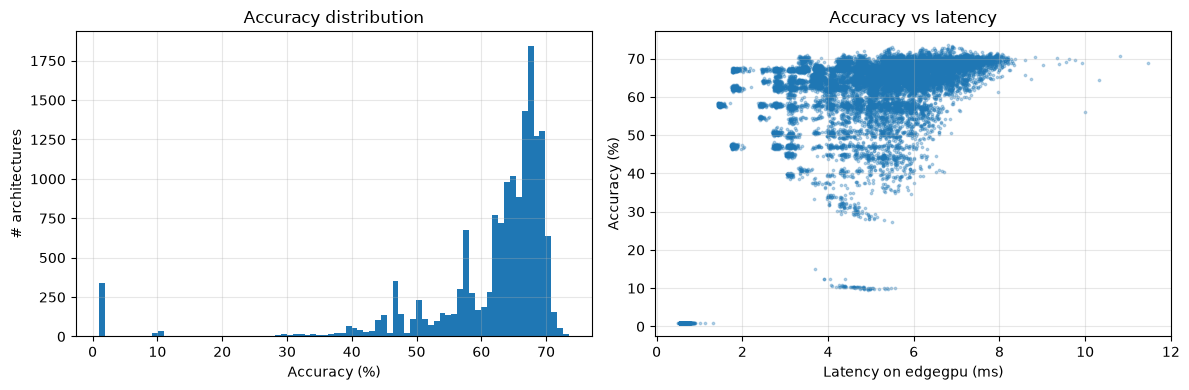

Best architecture: |nor_conv_3x3~0|+|nor_conv_3x3~0|nor_conv_3x3~1|+|skip_connect~0|nor_conv_3x3~1|nor_conv_3x3~2| → 73.49%
99th percentile of accuracy: 71.03


In [3]:
print(df[["acc", "test_acc", "lat", "energy", "cost", "flops", "params"]].describe().round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df["acc"], bins=80, color="tab:blue")
ax[0].set(xlabel="Accuracy (%)", ylabel="# architectures", title="Accuracy distribution")
ax[1].scatter(df["lat"], df["acc"], s=3, alpha=0.3)
ax[1].set(xlabel=f"Latency on {DEVICE} (ms)", ylabel="Accuracy (%)", title="Accuracy vs latency")
plt.tight_layout(); plt.show()

best = df.loc[df["acc"].idxmax()]
print("Best architecture:", best["arch_str"], f"→ {best['acc']:.2f}%")
print("99th percentile of accuracy:", np.percentile(df["acc"], 99).round(2))

### Questions — NAS vs Hyperparameter tuning

Some questions?

## 3. The search space: cell-based design

In NAS-Bench-201, the network consists of a fixed skeleton (stem, 3 stages of stacked cells, reduction blocks between stages, classifier). Search concerns only the cell, which is then repeated.

The cell is a DAG with 4 nodes (0 = input, 3 = output). Each pair of nodes $i<j$ is connected by an edge, for a total of 6 edges, and on each edge one operation is chosen from:

| operation | meaning |
| --- | --- |
| `none` | absent edge (zero) |
| `skip_connect` | identity |
| `nor_conv_1x1` | ReLU-Conv1x1-BN |
| `nor_conv_3x3` | ReLU-Conv3x3-BN |
| `avg_pool_3x3` | 3x3 average pooling |

Each node sums the contributions of incoming edges.

In [ ]:
draw_cell(best, title=f"Best architecture ({best['acc']:.2f}%)")

In [ ]:
o = Oracle(df, budget=3)
print(o.query(0), o.query(1), o.query(0), "| queries used:", o.n_queries)   # re-query is free
print("Best so far:", o.best())

## 9. NAS hardware-aware

HW-NAS-Bench ci dà le metriche hardware: possiamo cercare la rete più accurata **che rispetti un vincolo di latenza**, oppure studiare il compromesso accuratezza/latenza tramite il **fronte di Pareto**.

Nota: misurare la latenza è (in questo setting) molto più economico che addestrare la rete, quindi possiamo assumere di conoscerla **gratis** per ogni architettura, prima di valutarla.

In [ ]:
def pareto_front(acc, lat):
    # Indici delle architetture non dominate (acc alta, latenza bassa)
    order = np.argsort(lat)
    front, best = [], -np.inf
    for i in order:
        if acc[i] > best:
            front.append(i); best = acc[i]
    return np.array(front)

if df["lat"].notna().any():
    pf = pareto_front(df["acc"].to_numpy(), df["lat"].to_numpy())
    plt.scatter(df["lat"], df["acc"], s=3, alpha=0.2, label="tutte")
    plt.plot(df["lat"].iloc[pf], df["acc"].iloc[pf], "r.-", label="fronte di Pareto")
    plt.xlabel("Latenza"); plt.ylabel("Accuratezza (%)"); plt.legend(); plt.show()
    print(f"Architetture sul fronte: {len(pf)}")
else:
    print("Nessuna colonna di latenza nel CSV: sezione non disponibile.")

### ✏️ ESERCIZIO 6 — Ricerca con vincolo di latenza

Scegliamo come vincolo la mediana della latenza. Modificate Random Search e BO in modo che **valutino solo architetture ammissibili** (latenza ≤ `LAT_MAX`). Confrontate il regret rispetto alla migliore architettura *ammissibile*.

Suggerimento: basta restringere l'insieme dei candidati.

In [ ]:
LAT_MAX = df["lat"].median()
FEASIBLE = np.flatnonzero(df["lat"].to_numpy() <= LAT_MAX)
BEST_FEAS = df["acc"].iloc[FEASIBLE].max()
print(f"Vincolo: latenza ≤ {LAT_MAX:.3f}  | ammissibili: {len(FEASIBLE)}  | best ammissibile: {BEST_FEAS:.2f}%")


def random_search_constrained(oracle, seed=0):
    rng = np.random.default_rng(seed)
    for idx in rng.permutation(FEASIBLE):
        if oracle.remaining() <= 0:
            break
        oracle.query(idx)
    return oracle


def bo_constrained(oracle, n_init=10, xi=0.01, seed=0):
    rng = np.random.default_rng(seed)
    observed = list(rng.choice(FEASIBLE, size=n_init, replace=False))
    y = [oracle.query(i) for i in observed]
    feas_mask = np.zeros(N_ARCH, dtype=bool); feas_mask[FEASIBLE] = True
    while oracle.remaining() > 0:
        gp = make_gp(seed); gp.fit(X_ALL[observed], np.array(y))
        mask = feas_mask.copy(); mask[observed] = False
        cand = np.flatnonzero(mask)
        mu, sigma = gp.predict(X_ALL[cand], return_std=True)
        nxt = int(cand[np.argmax(expected_improvement(mu, sigma, max(y), xi))])
        observed.append(nxt); y.append(oracle.query(nxt))
    return oracle

In [ ]:
def run_many_c(algo, n_runs=N_RUNS):
    out = []
    for s in range(n_runs):
        c = algo(Oracle(df, BUDGET, seed=s), seed=s).incumbent_curve()
        out.append(BEST_FEAS - np.pad(c, (0, BUDGET - len(c)), mode="edge"))
    return np.array(out)

res_c = {"RS vincolata": run_many_c(random_search_constrained),
         "BO vincolata": run_many_c(bo_constrained)}
plot_regret(res_c, f"Regret con vincolo latenza ≤ {LAT_MAX:.3f}")

### ❓ Domande — Hardware-aware NAS
1. La migliore architettura in assoluto è ammissibile? Quanta accuratezza "si perde" imponendo il vincolo?
2. Un'alternativa al vincolo rigido è una **funzione obiettivo scalarizzata**, ad esempio $\mathrm{acc}(x) - \lambda\,\mathrm{lat}(x)$ (approccio usato in MnasNet con una forma moltiplicativa). Quali pro e contro rispetto al vincolo?
3. *(Facoltativo)* Ripetete con la latenza di un altro dispositivo presente nel CSV. Le architetture ottime cambiano? Cosa ci dice questo sulla trasferibilità tra dispositivi?

## 10. Bonus — Uno sguardo ad altri algoritmi

### 10.1 Algoritmi evolutivi: *Regularized Evolution* (Real et al., 2019)

Si mantiene una **popolazione** di architetture. A ogni passo:
1. si estrae un **campione** casuale di `S` individui dalla popolazione (*tournament selection*);
2. il migliore del campione diventa **genitore** e viene **mutato** (si cambia l'operazione su un arco a caso);
3. il figlio viene valutato e inserito; l'individuo **più vecchio** viene rimosso (*aging*: questa è la "regolarizzazione").

In [ ]:
from collections import deque

def mutate(ops, rng):
    ops = list(ops)
    e = rng.integers(6)
    ops[e] = rng.choice([o for o in OPS if o != ops[e]])
    return tuple(ops)


def regularized_evolution(oracle, pop_size=20, sample_size=5, seed=0):
    rng = np.random.default_rng(seed)
    population = deque()
    for idx in rng.choice(N_ARCH, size=pop_size, replace=False):
        population.append((df["ops"].iat[idx], oracle.query(idx)))
    while oracle.remaining() > 0:
        sample = [population[i] for i in rng.choice(len(population), sample_size, replace=False)]
        parent = max(sample, key=lambda t: t[1])[0]
        child = mutate(parent, rng)
        while ARCH2IDX[child] in oracle.cache and oracle.remaining() > 0:
            child = mutate(child, rng)   # evitiamo di "sprecare" mutazioni già viste
        population.append((child, oracle.query_ops(child)))
        population.popleft()
    return oracle


results["Reg. Evolution"] = run_many(regularized_evolution)
plot_regret(results)

### 10.2 Reinforcement Learning (Zoph & Le, 2017) — versione minimale

Un **controller** definisce una distribuzione sulle architetture; qui, per semplicità, è una distribuzione categorica indipendente per ciascun arco, con logit $\theta_{e,o}$ (nel lavoro originale è una RNN). Si campiona un'architettura, la si valuta, e si aggiornano i logit con **REINFORCE**:
$$
\theta \leftarrow \theta + \eta\,(R - b)\,\nabla_\theta \log p_\theta(\text{arch})
$$
dove $R$ è l'accuratezza e $b$ una baseline (media mobile) che riduce la varianza.

In [ ]:
def reinforce_search(oracle, lr=0.1, baseline_decay=0.9, seed=0):
    rng = np.random.default_rng(seed)
    theta = np.zeros((6, len(OPS)))
    baseline = None
    while oracle.remaining() > 0:
        p = np.exp(theta - theta.max(1, keepdims=True)); p /= p.sum(1, keepdims=True)
        choice = [rng.choice(len(OPS), p=p[e]) for e in range(6)]
        ops = tuple(OPS[c] for c in choice)
        R = oracle.query_ops(ops)
        baseline = R if baseline is None else baseline_decay * baseline + (1 - baseline_decay) * R
        adv = (R - baseline) / 10.0           # scala del reward (punti %)
        for e, c in enumerate(choice):        # grad log-softmax = onehot - p
            grad = -p[e]; grad[c] += 1
            theta[e] += lr * adv * grad
    return oracle

results["REINFORCE"] = run_many(reinforce_search)
plot_regret(results)